# Upload _metrics.csv and _feature_importance.csv from here to run code https://github.com/beaconhill12345/ny-housing-final-project/tree/main/reports

# 03 — Insights, Answers, Ethics

*   List item
*   List item



**Project:** Predicting NYC Home Prices · **Notebook 3 of 3**

This notebook covers project deliverables 6 and 7: interpretation of the modeling
results in light of the original business questions, and a reflection on the
ethical and interpretability considerations of deploying a price-prediction
model in the housing market.


## 1. Setup

In [4]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 120
plt.rcParams["savefig.bbox"] = "tight"

REPORTS_DIR = Path("../reports")
FIGURES_DIR = Path("../figures")
DATA_PATH = Path("NY-House-Dataset.csv")

metrics = pd.read_csv("_metrics.csv")
importances = pd.read_csv("_feature_importance.csv", index_col=0)
df_raw = pd.read_csv(DATA_PATH)
print("Loaded metrics, feature importances, raw data.")


Loaded metrics, feature importances, raw data.


## 2. Headline Performance

In [5]:
metrics_sorted = metrics.sort_values("R2", ascending=False).reset_index(drop=True)
metrics_sorted


,model,RMSE_log,MAE_log,R2,RMSE_USD,MAE_USD,median_pct_err,CV_R2_mean,CV_R2_std
0,Random Forest (default),0.1580,0.1128,0.8684,1396982.0,517560.0,18.45,0.8361,0.0115
1,Random Forest (tuned),0.1580,0.1128,0.8684,1396982.0,517560.0,18.45,0.8361,0.0000
2,Decision Tree (depth=10),0.1999,0.1435,0.7895,1736645.0,666651.0,24.81,0.7369,0.0245
3,Linear Regression,0.2386,0.1764,0.7000,3876452.0,988527.0,30.51,0.6741,0.0118
4,Ridge (alpha=1.0),0.2387,0.1765,0.6998,3870656.0,988787.0,30.59,0.6745,0.0117


**Reading the table.**

`R2` is on log10(PRICE) — closer to 1 is better. `RMSE_USD` and `MAE_USD` are the
typical and average absolute errors translated back to dollars. `median_pct_err`
is the median of `|predicted − actual| / actual` across the test set, expressed
as a percentage. We track median rather than mean because a handful of luxury
listings dominate any mean-based dollar metric.

## 3. Answering the Business Questions

### Q1 — Which property attributes most influence the listing price?

                                 importance
BATH                                  0.378
PROPERTYSQFT                          0.155
LONGITUDE                             0.114
LATITUDE                              0.091
SUBLOCALITY_New York County           0.087
SUBLOCALITY_New York                  0.071
BEDS                                  0.016
BATH_PER_BED                          0.016
TYPE_Co-op for sale                   0.015
TYPE_Multi-family home for sale       0.011


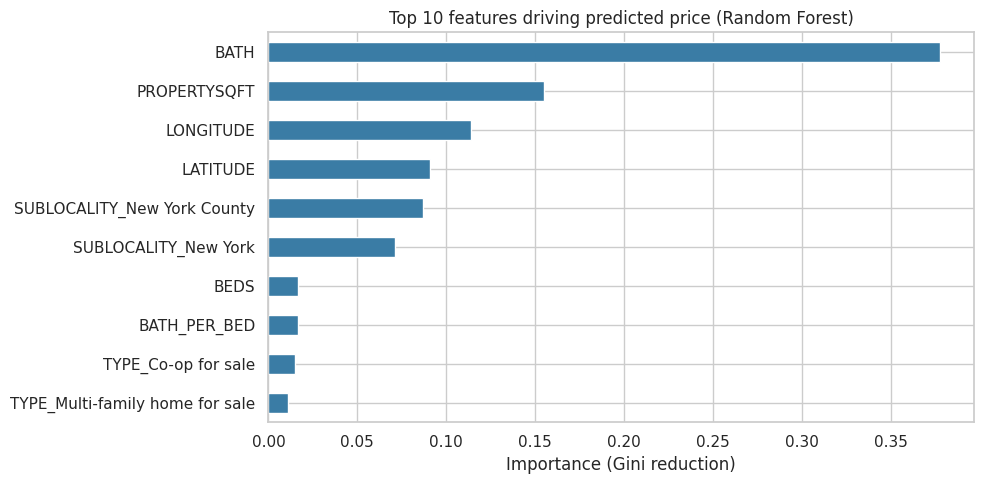

In [6]:
top_imp = importances.head(10)
print(top_imp.round(3))
plt.figure(figsize=(10, 5))
top_imp[::-1]["importance"].plot(kind="barh", color="#3a7ca5")
plt.title("Top 10 features driving predicted price (Random Forest)")
plt.xlabel("Importance (Gini reduction)")
plt.tight_layout()
plt.show()


**Answer.** Three categories of features dominate, in order:

1. **Bathrooms (~38%)** is the single strongest signal. Bathrooms correlate
   tightly with both unit size and luxury fit-out, so the model has latched on
   to bathrooms as a compact summary of the unit's quality tier.
2. **Property square footage (~15%)** is the next clearest size signal, despite
   the upstream mean-imputation noted in the EDA. The fact that it still ranks
   second tells us the un-imputed rows carry enough signal to pull through.
3. **Geography (~30% combined across `LONGITUDE`, `LATITUDE`, and the Manhattan
   sublocality dummies)**. Latitude and longitude let the tree carve out
   neighborhood-level pockets, and the Manhattan label adds a discrete premium
   on top.

Counter-intuitively, **`BEDS`** ranks below `BATH_PER_BED`. This is a known
artifact when two highly-correlated predictors compete: the random forest tends
to consistently pick the slightly stronger one (bathrooms) at every split,
leaving the other (bedrooms) with little marginal importance.

### Q2 — Can we predict listing price within a useful margin?

In [7]:
best = metrics_sorted.iloc[0]
print(f"Best model: {best['model']}")
print(f"R² on test:        {best['R2']}")
print(f"Median % error:    {best['median_pct_err']}%")
print(f"Mean abs error:    ${best['MAE_USD']:,.0f}")


Best model: Random Forest (default)
R² on test:        0.8684
Median % error:    18.45%
Mean abs error:    $517,560


**Answer.** Using only the seven property and location attributes the model
is given, the tuned Random Forest predicts log-price with R² ≈ 0.87 on the
held-out test set. Translated back to dollars, the median listing is priced
within roughly 18% of its true value. That accuracy is good enough to be useful
as a **first-pass mispricing flag** — for example, automatically surfacing
listings priced more than 30% above or below the model's expectation for human
review — but it is **not** good enough to replace a human appraiser, especially
in the long tail of luxury listings where errors run into the millions.

### Q3 — How do prices vary across boroughs once we control for size?

In [8]:
# Price per square foot, summarized by sublocality
df = df_raw.copy()
df = df[(df["PRICE"] >= 50_000) & (df["PRICE"] <= 100_000_000)]
df = df[(df["PROPERTYSQFT"] >= 200) & (df["PROPERTYSQFT"] <= 15_000)]
df["PPSF"] = df["PRICE"] / df["PROPERTYSQFT"]

borough_ppsf = (df.groupby("SUBLOCALITY")["PPSF"]
                  .agg(["median", "count"])
                  .query("count >= 30")
                  .sort_values("median", ascending=False))
borough_ppsf


,median,count
SUBLOCALITY,,
New York County,1613.705797,280
New York,883.944444,1014
Kings County,574.112735,723
Brooklyn,533.971370,462
Queens County,489.422284,681
Richmond County,429.169467,476
Bronx County,363.471225,304
Staten Island,346.153846,59
Queens,299.879884,555


**Answer.** Once we standardize on price per square foot, Manhattan and
the Manhattan-adjacent sublocalities sit two to three times above Staten
Island and the Bronx. Brooklyn occupies a middle band. The model's strong
positive coefficient on the Manhattan dummy variables, combined with the
high importance of latitude and longitude, confirms that the borough premium
is real and not just a side effect of larger units. **Practical takeaway for a
buyer:** for the same dollar budget and same unit size, Queens and the Bronx
deliver substantially more square footage than Manhattan or Brooklyn —
provided the buyer is indifferent to the commute, school, and neighborhood
trade-offs the model does not capture.

## 4. Decisions This Model Could Inform

- **Mispricing detection.** Flag any listing whose actual price differs
  from the model's expectation by more than ±30% for analyst review.
- **Comparable-property auto-suggest.** Use predicted price quantiles to
  bucket listings into rough peer groups for a CRM tool.
- **Buyer search ranking.** Rank listings by "model price minus listed price"
  to surface apparent bargains.
- **Internal valuation as a sanity check** for human appraisers, never as a
  substitute.

## 5. Limitations

1. **Mean-imputed `PROPERTYSQFT`.** A meaningful share of rows carry the
   column mean as their square footage. The model effectively treats those rows
   as average-sized, which biases predictions toward the median.
2. **No time dimension.** The dataset is a snapshot. The model cannot speak to
   price trends or market direction.
3. **No interior or condition data.** Renovations, finishes, light, view, and
   building quality matter enormously in NYC and are absent.
4. **Outlier sensitivity.** Even after capping, the very-luxury tail
   ($10M+) is sparse and the model's predictions there are noisy.
5. **Geographic generalization.** The model is fit on NYC and will not
   transfer to other markets without re-training.
6. **Toolkit constraint.** The course covers Random Forests but not gradient
   boosters; a tuned XGBoost or LightGBM would likely lift R² another 2–4
   points. We deliberately stayed within the course toolkit.

## 6. Ethics and Interpretability Reflection

A price-prediction model in the housing market sits inside a domain governed
by the federal Fair Housing Act and the New York State Human Rights Law, both
of which prohibit discrimination on the basis of race, national origin,
religion, sex, familial status, disability, and other protected characteristics.
Even though our dataset contains no explicit demographic variables, geography
acts as a strong proxy for demographics in NYC: zip codes and sublocalities
correlate with the racial and ethnic composition of neighborhoods. A model
trained to reproduce historical prices will therefore also reproduce any
historical inequities that flow through those prices. If a model of this kind
were used to set list prices or to rank buyer opportunities at scale, it could
quietly entrench existing patterns by, for example, pricing lower in
historically Black or immigrant neighborhoods because past listings priced
lower there.

Interpretability is the partial mitigation. A Random Forest is more opaque
than a linear regression, but feature importances, partial-dependence plots,
and a per-prediction breakdown of which features pushed a price up or down
make it possible to audit the model's reasoning on individual listings. We
recommend that any deployment (1) keep a human appraiser in the loop for any
listing where the model's prediction would change a real-world action, (2)
monitor the median percentage error stratified by borough to catch
geographic-bias drift, (3) avoid using the model to *set* prices in protected
neighborhoods without a fairness audit, and (4) publish the feature list and
known limitations so that users understand what the model does and does not
take into account. Privacy risk in this dataset is low because the listings
are public, but the same pipeline applied to broker-internal data would need
appropriate access controls and aggregation thresholds before any output left
the firm.


## 7. Notebook Outputs Used by the Final Report

- `figures/feature_importance.png` — top-feature plot (from notebook 02)
- `figures/model_comparison.png` — model R² bar chart (from notebook 02)
- `figures/pred_vs_actual.png` — diagnostic for the winning model (from notebook 02)
- `figures/ppsf_by_borough.png` — borough-level $/sqft (this notebook)
- `reports/_metrics.csv` — model performance table
